In [32]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [35]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isna().sum()

np.int64(11)

In [36]:
df = df.dropna()

La variable TotalCharges venía como string debido a valores vacíos en clientes sin historial de facturación. La convertí a numérica y eliminé los registros incompletos 

In [37]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

churn_rate = df['Churn'].mean()
print(f"Churn rate: {churn_rate:.2%}")

Churn rate: 26.58%


El porcentaje de abandono de clientes es de ~26–27%, lo que indica un problema de retención importante

## EDA

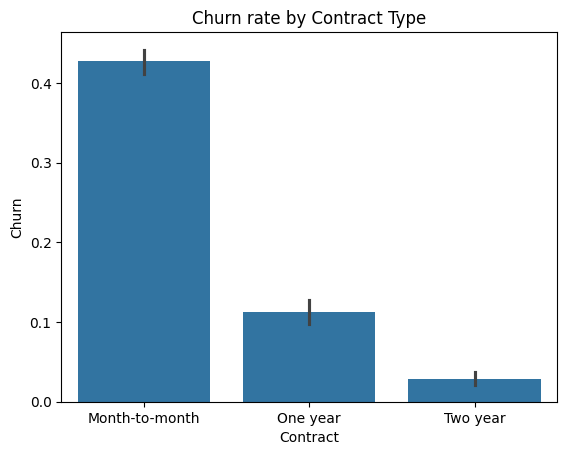

In [38]:
# Churn vs tipo de contrato
sns.barplot(x='Contract', y='Churn', data=df)
plt.title('Churn rate by Contract Type')
plt.show()

Los clientes con contratos mensuales presentan una tasa de abandono mayor, lo que sugiere menor compromiso y mayor sensibilidad al precio o competencia.

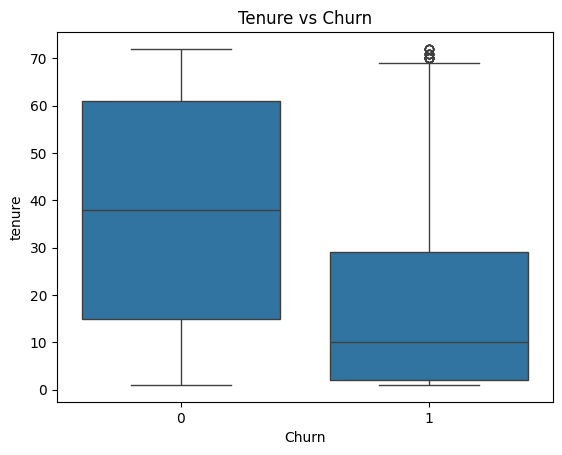

In [39]:
# Churn vs tiempo de contrato

sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()


El churn es significativamente mayor en clientes con baja antigüedad, indicando que el riesgo es más crítico en las primeros meses de contrato.

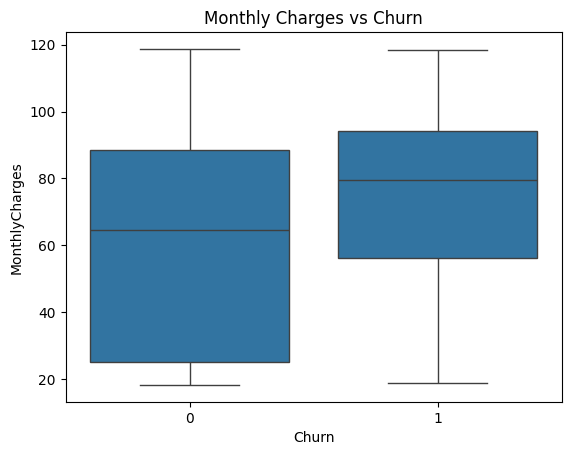

In [40]:
# Churn vs gasto mensual

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

Los clientes con mayor gasto mensual muestran mayor propensión a abandonar, posiblemente debido a sensibilidad al precio

In [41]:
df.groupby('Churn')[['tenure', 'MonthlyCharges']].mean()

,tenure,MonthlyCharges
Churn,,
0,37.650010,61.307408
1,17.979133,74.441332


## Feature engineering

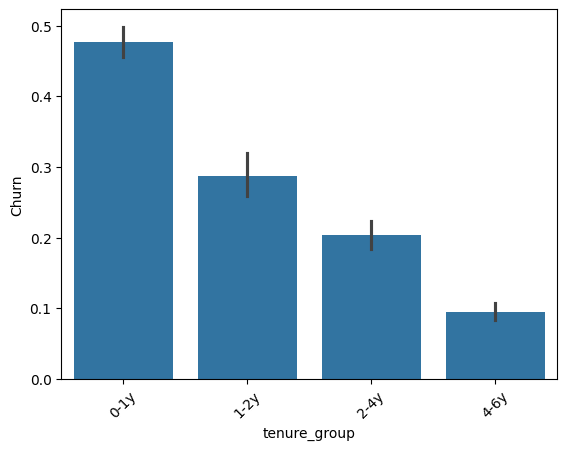

In [42]:
# Agrupación de la antigüedad para capturar diferencias en comportamiento entre clientes nuevos y consolidados
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], labels=['0-1y', '1-2y', '2-4y', '4-6y'])
sns.barplot(x='tenure_group', y='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

In [43]:
# Agrupamiento de los cargos mensuales en alto o no alto
threshold = df['MonthlyCharges'].quantile(0.75)

df['monthly_charges_high'] = (df['MonthlyCharges'] > threshold).astype(int)

## Preparar datos para el modelo

In [44]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='str')


/tmp/ipykernel_3119/4182786301.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [45]:
df = df.drop('customerID', axis=1)

In [46]:
df_encoded = pd.get_dummies(df, drop_first=True)

# Split

In [47]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Modelado

In [50]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

## Evaluación

In [52]:
from sklearn.metrics import roc_auc_score, classification_report

print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nLogistic Regression Report:\n", classification_report(y_test, y_pred_log))
print("\nRandom Forest Report:\n", classification_report(y_test, y_pred_rf))

Logistic Regression ROC-AUC: 0.8346348571990619
Random Forest ROC-AUC: 0.8189350368326507

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407


Random Forest Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Ajustar Treshold

In [62]:
import numpy as np

threshold = 0.3
y_pred_custom = (y_prob_log > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1033
           1       0.51      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407



Se compararon modelos de regresión logística y Random Forest, obteniendo mejor rendimiento con Logistic Regression (ROC-AUC 0.83). Se priorizó la detección de clientes en riesgo mediante ajuste de threshold, alineando el modelo con objetivos de retención.

El modelo base tenía un recall moderado, por lo que ajusté el threshold para priorizar la detección de clientes en riesgo. Esto permite capturar más churners, alineando el modelo con el objetivo de retención, donde es más costoso no detectar un cliente que se va

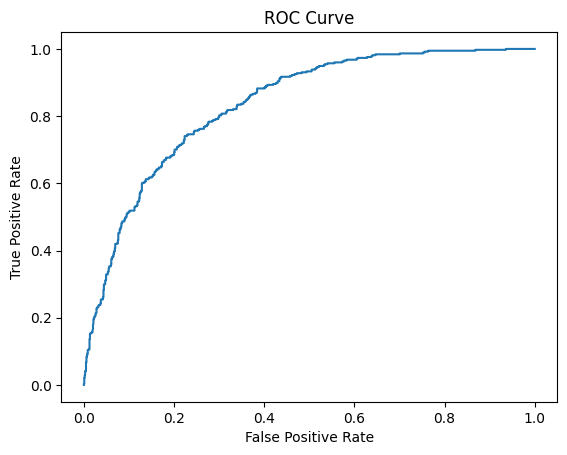

In [71]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob_log)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## Feature importance

In [73]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

TotalCharges                      0.177846
tenure                            0.160989
MonthlyCharges                    0.155839
InternetService_Fiber optic       0.040198
PaymentMethod_Electronic check    0.036093
gender_Male                       0.028347
Contract_Two year                 0.027459
PaperlessBilling_Yes              0.025727
OnlineSecurity_Yes                0.024169
Partner_Yes                       0.023462
dtype: float64


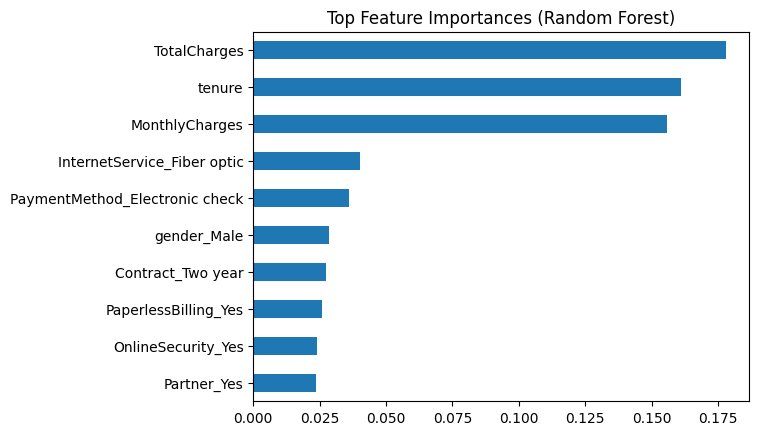

In [65]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top Feature Importances (Random Forest)")
plt.show()

- Clientes más antiguos se comportan distintos a los nuevos. Clientes nuevos más intestables (tenure) y los antiguos más fieles.
- Cuánto paga un cliente influye en si se queda o si se va. Clientes que pagan más -> más exigentes -> más riesgo
- Algunos servicios tienen más abandono que otros 
- La forma en la que el cliente interactúa con la empresa influye
- Clientes más comprometidos se van menos

El churn está principalmente explicado por la etapa del cliente, su valor económico, el tipo de servicio contratado y su nivel de compromiso con la empresa

In [66]:
coefficients = pd.Series(
    log_model.coef_[0],
    index=X.columns
).sort_values()

print(coefficients.head(10))   # más negativos
print(coefficients.tail(10))   # más positivos

tenure                            -1.241754
MonthlyCharges                    -0.760021
Contract_Two year                 -0.648362
Contract_One year                 -0.326861
tenure_group_1-2y                 -0.131815
OnlineSecurity_Yes                -0.129903
TechSupport_Yes                   -0.106873
Dependents_Yes                    -0.097284
TechSupport_No internet service   -0.086053
StreamingTV_No internet service   -0.086053
dtype: float64
SeniorCitizen                     0.076120
DeviceProtection_Yes              0.080939
PaperlessBilling_Yes              0.144897
PaymentMethod_Electronic check    0.176586
StreamingMovies_Yes               0.230387
MultipleLines_Yes                 0.231237
StreamingTV_Yes                   0.247616
tenure_group_4-6y                 0.249435
TotalCharges                      0.280212
InternetService_Fiber optic       0.715216
dtype: float64


Valores negativos -> disminuyen churn

Valores positivos -> aumentan churn

Los clientes con fibra tienen más probabilidad de irse

Algunos perfiles de uso o pago están asociados a mayor abandono

Cuanto más tiempo lleva un cliente, más estable es

## SIMULACION

In [74]:
df_results = X_test.copy()
df_results["churn_prob"] = y_prob_log
df_results["actual_churn"] = y_test.values

In [ ]:
# Calculamos el top 20 clientes más probables de abandono
df_results = df_results.sort_values(by='churn_prob', ascending=False)

top_20 = int(len(df_results) * 0.2)
df_target = df_results.head(top_20)


### Supuestos

In [76]:
cost_retention = 20       # € por cliente contactado
customer_value = 200      # € valor medio cliente
retention_rate = 0.3      # % de clientes que consigues retener

cada intento cuesta 20€

cada cliente vale 200€

solo consigo salvar al 30%

In [77]:
# clientes que realmente iban a hacer churn
real_churners = df_target['actual_churn'].sum()

# clientes salvados
saved_customers = real_churners * retention_rate

# ingresos salvados
revenue_saved = saved_customers * customer_value

# coste campaña
campaign_cost = len(df_target) * cost_retention

# beneficio neto
net_profit = revenue_saved - campaign_cost

print(f"Clientes contactados: {len(df_target)}")
print(f"Churners reales en target: {real_churners}")
print(f"Clientes salvados: {saved_customers:.0f}")
print(f"Ingresos salvados: €{revenue_saved:.2f}")
print(f"Coste campaña: €{campaign_cost:.2f}")
print(f"Beneficio neto: €{net_profit:.2f}")

Clientes contactados: 281
Churners reales en target: 186
Clientes salvados: 56
Ingresos salvados: €11160.00
Coste campaña: €5620.00
Beneficio neto: €5540.00


Utilicé el modelo para priorizar el 20% de clientes con mayor riesgo de churn. En este grupo, el churn se concentraba en más del 60%, lo que permitió diseñar una campaña de retención eficiente. Bajo supuestos conservadores, la estrategia generó un beneficio neto positivo, demostrando el valor del modelo en la toma de decisiones.